## 0. Install & import

In [ ]:

import sys, subprocess
def pipinstall(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])
pipinstall(["numpy", "pandas", "scipy", "matplotlib", "pymannkendall", "pyhomogeneity"])
print("done")

done


In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

try:
    import pymannkendall as mk
except Exception:
    mk = None
try:
    import pyhomogeneity as hg
except Exception:
    hg = None

pd.options.display.float_format = lambda x: f"{x:0.3f}"
print("imports ok | pymannkendall:", mk is not None, "| pyhomogeneity:", hg is not None)

imports ok | pymannkendall: True | pyhomogeneity: True


In [ ]:

DEMO_MODE = False          

# --- Paths ---
DATA_ROOT   = r"C:\Users\Apechhya Aryal\Downloads\Nepal\Nepal"  
OBS_DIR     = r"C:\Users\Apechhya Aryal\Desktop\forpaper\allmerged"   
OUTPUT_DIR  = r"C:\Users\Apechhya Aryal\Desktop\forpaper\outputs_cmip6"


SCN_HIST = "historical"
SCN_MAP  = {"ssp245": "ssp245", "ssp585": "ssp585"}  
VAR_FILES = {"P": "PrecipData", "Tmax": "TMaxData", "Tmin": "TMinData"}  
DELIM = None              # None = any whitespace; set "," if the read step fails
HEADER_LON_ROW = 0        # row holding longitudes
HEADER_LAT_ROW = 1        # row holding latitudes
N_INDEX_COLS   = 3        # leading cols = year, month, day

# --- GCM selection ---
ALL_13 = ["ACCESS-CM2","ACCESS-ESM1-5","BCC-CSM2-MR","CanESM5","EC-Earth3",
          "EC-Earth3-Veg","INM-CM4-8","INM-CM5-0","MPI-ESM1-2-HR","MPI-ESM1-2-LR",
          "MRI-ESM2-0","NorESM2-LM","NorESM2-MM"]
# Citation-backed robustness subset (Hussain et al. 2025 + DHM-4 overlap):
SUBSET = ["EC-Earth3","EC-Earth3-Veg","NorESM2-MM","MPI-ESM1-2-HR"]
GCMS = ALL_13             # ALL 13 models. Switch to SUBSET for the robustness run.

SCENARIOS = ["ssp245", "ssp585"]

STATIONS = {
    "Jomsom":      (28.78401, 83.72982, 2741),
    "Thakmarpha":  (28.73887, 83.68183, 2655),
    "Lete":        (28.63273, 83.60922, 2490),
    "Ranipauwa":   (28.81556, 83.86222, 3671),
    "Samar Gaun":  (28.96202, 83.80163, 3610),   
    "Dhakarjhong": (28.82359, 83.73951, 3200),
    "Chhoser":     (29.22713, 83.97982, 3886),
}

# --- Periods ---
BASELINE   = (1981, 2014)
FUTURE_WINDOWS = {
    "near (2021-2050)": (2021, 2050),
    "mid (2051-2080)":  (2051, 2080),
    "far (2081-2100)":  (2081, 2100),   
}

# --- Indices ---
SPEI_DIST   = "pearson3"      
SPI_DIST    = "gamma"
TIMESCALES  = [3, 6, 12]
PET_SCALE   = 1.0             
DROUGHT_THRESHOLD = -1.0
# ===============================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config loaded. DEMO_MODE =", DEMO_MODE, "| GCMs:", len(GCMS), "| scenarios:", SCENARIOS)

Config loaded. DEMO_MODE = False | GCMs: 13 | scenarios: ['ssp245', 'ssp585']


In [ ]:
import re

def read_grid_file(path, delim=DELIM, lon_row=HEADER_LON_ROW,
                   lat_row=HEADER_LAT_ROW, nidx=N_INDEX_COLS):
    """Fast reader. Coordinates parsed from the first two lines (robust to leading blanks),
    body read with the C parser."""
    with open(path) as f:
        l0 = f.readline(); l1 = f.readline()
    pat = r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?'
    lons = np.array(re.findall(pat, l0), dtype=float)
    lats = np.array(re.findall(pat, l1), dtype=float)
    if delim is None:
        body = np.loadtxt(path, skiprows=2)             
    else:
        body = pd.read_csv(path, header=None, skiprows=2, sep=delim).to_numpy(float)
    ymd  = body[:, :nidx].astype(int)
    vals = body[:, nidx:]
    nc = vals.shape[1]
    if len(lons) > nc: lons = lons[-nc:]
    if len(lats) > nc: lats = lats[-nc:]
    dates = pd.to_datetime(dict(year=ymd[:,0], month=ymd[:,1], day=ymd[:,2]), errors="coerce")
    return lons, lats, dates, vals


def haversine(lat1, lon1, lat2, lon2):
    R=6371.0; p1,p2=np.radians(lat1),np.radians(lat2)
    dphi=np.radians(lat2-lat1); dl=np.radians(lon2-lon1)
    a=np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def nearest_cell(lons, lats, stn_lat, stn_lon):
    d=haversine(stn_lat, stn_lon, lats, lons); j=int(np.nanargmin(d)); return j, float(d[j])

VAR_KEYS = {"P":["precip","prec","rainfall","rain","ppt","pcp"],
            "Tmax":["tempmax","tmax","tasmax","maxtemp","max"],
            "Tmin":["tempmin","tmin","tasmin","mintemp","min"]}

def var_path(model, scenario_folder, var):
    folder=os.path.join(DATA_ROOT, model, scenario_folder)
    if not os.path.isdir(folder): raise FileNotFoundError(f"folder missing: {folder}")
    base=os.path.join(folder, VAR_FILES[var])
    if os.path.exists(base): return base
    hits=glob.glob(base+".*")
    if hits: return hits[0]
    files=[f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder,f))]
    for k in VAR_KEYS[var]:
        for f in files:
            if k in f.lower(): return os.path.join(folder, f)
    raise FileNotFoundError(f"No '{var}' file in {folder}. Files present: {files}")

def extract_station_series(model, scenario_folder, var, stn_lat, stn_lon, verbose=False):
    lons,lats,dates,vals=read_grid_file(var_path(model,scenario_folder,var))
    j,dist=nearest_cell(lons,lats,stn_lat,stn_lon)
    if verbose: print(f"  {model}/{scenario_folder}/{var}: grid {vals.shape}, {dist:.1f} km")
    s=pd.Series(vals[:,j], index=dates).dropna()
    return s[~s.index.duplicated()].sort_index()

def preload_station_data(stations, models, scen_folders, verbose=True):
    """Read each grid file ONCE; keep only the nearest-cell series per station.
    Returns data[(model, scen_folder)][var] = DataFrame(index=date, columns=station)."""
    data={}
    for mi, model in enumerate(models, 1):
        for scen in scen_folders:
            vf={}
            for var in ["P","Tmax","Tmin"]:
                try: path=var_path(model, scen, var)
                except FileNotFoundError as ex:
                    if verbose: print("   missing:", ex); 
                    continue
                lons,lats,dates,vals=read_grid_file(path)
                ser={}
                for sname,(lat,lon,_) in stations.items():
                    j,_=nearest_cell(lons,lats,lat,lon)
                    s=pd.Series(vals[:,j], index=dates).dropna()
                    ser[sname]=s[~s.index.duplicated()].sort_index()
                vf[var]=pd.DataFrame(ser)
            data[(model,scen)]=vf
        if verbose: print(f"   read {model}  ({mi}/{len(models)})")
    return data

In [ ]:
# Match station by FILENAME (spaces/underscores ignored). Precip required; temp optional.
COLMAP={"P":["precip","prec","rainfall","rain","ppt","pcp"],
        "Tmax":["tmax","t_max","maxtemp","max_temp","tx"],
        "Tmin":["tmin","t_min","mintemp","min_temp","tn"]}
def _norm(s): return re.sub(r"[^a-z0-9]","",str(s).lower())
def _find_col(cols,keys,exact=None):
    for c in cols:
        lc=str(c).strip().lower()
        if (exact and lc==exact) or any(k in lc for k in keys): return c
    return None
def _find_date(df):
    for c in df.columns:
        if "date" in str(c).lower() or str(c).lower() in ("time","day"): return c
    return df.columns[0]
def load_observed_station(name):
    key=_norm(name)
    files=[f for f in glob.glob(os.path.join(OBS_DIR,"*"))
           if key in _norm(os.path.basename(f)) and f.lower().endswith((".csv",".txt"))]
    if not files: raise FileNotFoundError(f"No files matching '{name}' in {OBS_DIR}")
    merged=None
    for fp in files:
        df=pd.read_csv(fp); dcol=_find_date(df)
        df[dcol]=pd.to_datetime(df[dcol], errors="coerce"); df=df.dropna(subset=[dcol]).set_index(dcol)
        got={}
        for var,keys in COLMAP.items():
            col=_find_col(df.columns,keys,exact="p" if var=="P" else None)
            if col is not None: got[var]=pd.to_numeric(df[col], errors="coerce")
        if got:
            part=pd.DataFrame(got); merged=part if merged is None else merged.combine_first(part)
    if merged is None or "P" not in merged.columns:
        raise ValueError(f"{name}: no precipitation column in {[os.path.basename(f) for f in files]}")
    for v in ["Tmax","Tmin"]:
        if v not in merged.columns: merged[v]=np.nan
    if merged[["Tmax","Tmin"]].notna().to_numpy().sum()==0:
        print(f"  [note] {name}: no observed temperature -> SPI only (SPEI skipped).")
    return merged[["P","Tmax","Tmin"]].sort_index()

In [ ]:
GSC = 0.0820  # MJ m-2 min-1

def extraterrestrial_radiation_mm(lat_deg, doy):
    """Ra converted to mm/day (Allen et al. 1998)."""
    phi = np.radians(lat_deg)
    dr  = 1 + 0.033*np.cos(2*np.pi/365*doy)
    dec = 0.409*np.sin(2*np.pi/365*doy - 1.39)
    x = -np.tan(phi)*np.tan(dec)
    ws = np.arccos(np.clip(x, -1, 1))
    ra = (24*60/np.pi)*GSC*dr*(ws*np.sin(phi)*np.sin(dec) +
                               np.cos(phi)*np.cos(dec)*np.sin(ws))
    return ra * 0.408  # MJ m-2 d-1 -> mm/day

def hargreaves_pet_daily(tmax, tmin, lat_deg, scale=1.0):
    doy = tmax.index.dayofyear.to_numpy()
    ra  = extraterrestrial_radiation_mm(lat_deg, doy)
    tmean = (tmax.to_numpy() + tmin.to_numpy())/2
    tr = np.clip(tmax.to_numpy() - tmin.to_numpy(), 0, None)
    pet = 0.0023*scale*ra*(tmean + 17.8)*np.sqrt(tr)
    return pd.Series(np.clip(pet, 0, None), index=tmax.index, name="PET")

def to_monthly(daily_df):
    """Monthly P, PET sums and Tmax/Tmin means from a daily frame with PET."""
    agg = {"P": "sum", "PET": "sum"}
    if "Tmax" in daily_df: agg["Tmax"] = "mean"
    if "Tmin" in daily_df: agg["Tmin"] = "mean"
    return daily_df.resample("MS").agg(agg)

In [ ]:
def _fit_dist(name, x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if name == "gamma":
        nz = x[x > 0]; q0 = 1 - len(nz)/len(x) if len(x) else 1.0
        if len(nz) < 5: return ("gamma", None, q0)
        a, loc, scl = stats.gamma.fit(nz, floc=0)
        return ("gamma", (a, loc, scl), q0)
    if name == "loglogistic":
        c, loc, scl = stats.fisk.fit(x)
        return ("fisk", (c, loc, scl), 0.0)
    if name == "pearson3":
        sk, loc, scl = stats.pearson3.fit(x)
        return ("pearson3", (sk, loc, scl), 0.0)
    raise ValueError(name)

def _cdf(fit, x):
    name, params, q0 = fit
    if params is None:
        return np.where(np.asarray(x) <= 0, q0/2, q0)
    dist = getattr(stats, name)
    if name == "gamma":
        return q0 + (1 - q0)*dist.cdf(x, *params)
    return dist.cdf(x, *params)

def fit_params(monthly_series, scale, dist_name, baseline):
    """Fit the index distribution per calendar month on the BASELINE window.
    Returns {month: fit}. Use with apply_params so future series are scored
    against the OBSERVED baseline (this is what makes the shift meaningful)."""
    acc = monthly_series.rolling(scale).sum()
    b0, b1 = baseline
    params = {}
    for m in range(1, 13):
        v = acc[(acc.index.month==m) & (acc.index.year>=b0) & (acc.index.year<=b1)].dropna()
        params[m] = _fit_dist(dist_name, v.values) if len(v) >= 5 else None
    return params

def apply_params(monthly_series, scale, dist_name, params):
    """Standardize a series using PRE-FIT params (from fit_params)."""
    acc = monthly_series.rolling(scale).sum()
    z = pd.Series(index=acc.index, dtype=float)
    for m in range(1, 13):
        if params.get(m) is None: continue
        mask = acc.index.month == m
        p = np.clip(_cdf(params[m], acc[mask].values), 1e-6, 1-1e-6)
        z.loc[mask] = stats.norm.ppf(p)
    return z

def standardize(monthly_series, scale, dist_name, baseline):
    """Fit on baseline subset of THIS series, apply to the whole series.
    Correct for the transient (its baseline part is the real observed record)."""
    return apply_params(monthly_series, scale, dist_name,
                        fit_params(monthly_series, scale, dist_name, baseline))

def spi(monthly_df, scale, baseline):
    return standardize(monthly_df["P"], scale, SPI_DIST, baseline)

def spei(monthly_df, scale, baseline):
    return standardize(monthly_df["P"] - monthly_df["PET"], scale, SPEI_DIST, baseline)

## 6. Delta-change factors

For each calendar month, additive deltas for Tmax/Tmin and a multiplicative factor for P,
computed from each model's **own** historical (1981–2014) vs the chosen future window.
Then applied to the observed baseline to build a future-analog daily series.

In [ ]:
def monthly_deltas(model_hist, model_future):
    """model_hist / model_future: daily DataFrames with P, Tmax, Tmin.
    Returns dict month -> (dTmax, dTmin, fP)."""
    h = model_hist.groupby(model_hist.index.month).mean(numeric_only=True)
    f = model_future.groupby(model_future.index.month).mean(numeric_only=True)
    out = {}
    for m in range(1, 13):
        if m not in h.index or m not in f.index:
            out[m] = (0.0, 0.0, 1.0); continue
        dTmax = f.loc[m, "Tmax"] - h.loc[m, "Tmax"]
        dTmin = f.loc[m, "Tmin"] - h.loc[m, "Tmin"]
        hp = h.loc[m, "P"]
        fP = (f.loc[m, "P"]/hp) if hp > 1e-6 else 1.0
        fP = float(np.clip(fP, 0.1, 5.0))   # guard pathological ratios
        out[m] = (float(dTmax), float(dTmin), fP)
    return out

def apply_deltas(obs_daily, deltas):
    """Perturb observed baseline daily series with monthly deltas -> future-analog."""
    out = obs_daily.copy()
    mo = out.index.month
    dmax = np.array([deltas[m][0] for m in mo])
    dmin = np.array([deltas[m][1] for m in mo])
    fp   = np.array([deltas[m][2] for m in mo])
    out["Tmax"] = out["Tmax"] + dmax
    out["Tmin"] = out["Tmin"] + dmin
    out["P"]    = np.clip(out["P"].to_numpy() * fp, 0, None)
    # keep Tmax >= Tmin after perturbation
    swap = out["Tmax"] < out["Tmin"]
    out.loc[swap, ["Tmax", "Tmin"]] = out.loc[swap, ["Tmin", "Tmax"]].values
    return out

def slice_years(daily, yr0, yr1):
    return daily[(daily.index.year >= yr0) & (daily.index.year <= yr1)]

## 7. Trend & change-point tests

In [ ]:
def mk_trend(series):
    s = pd.Series(series).dropna()
    if mk is None or len(s) < 10:
        return dict(trend="n/a", p=np.nan, slope=np.nan)
    r = mk.hamed_rao_modification_test(s.values)
    return dict(trend=r.trend, p=float(r.p), slope=float(r.slope))

def pettitt_change(series):
    s = pd.Series(series).dropna()
    if len(s) < 10:
        return dict(cp_index=None, p=np.nan)
    if hg is not None:
        r = hg.pettitt_test(s.values)
        idx = int(r.cp); p = float(r.p)
    else:                                  # lightweight fallback
        x = s.values; n = len(x)
        r = stats.rankdata(x); U = np.array([2*r[:k].sum() - k*(n+1) for k in range(1, n+1)])
        idx = int(np.argmax(np.abs(U))); K = np.abs(U).max()
        p = float(2*np.exp(-6*K**2/(n**3 + n**2)))
    when = s.index[idx]
    return dict(cp_index=idx, cp_date=when, p=p)

In [ ]:
_PRELOAD = None   # cache so re-runs don't re-read files

def run_pipeline(scale=12, reuse=True):
    global _PRELOAD
    import time
    scen_folders=[SCN_HIST]+[SCN_MAP[s] for s in SCENARIOS]
    if _PRELOAD is None or not reuse:
        print("Reading grid files once (this is the slow part)...")
        t0=time.time(); _PRELOAD=preload_station_data(STATIONS, GCMS, scen_folders)
        print(f"   grid read finished in {time.time()-t0:0.0f}s")
    P=_PRELOAD; rows=[]
    for sname,(lat,lon,_) in STATIONS.items():
        obs=load_observed_station(sname)
        obs_base=slice_years(obs,*BASELINE).copy()
        has_temp=(obs_base["Tmax"].notna().sum()>0) and (obs_base["Tmin"].notna().sum()>0)
        # ---- distributions fit ONCE on the OBSERVED baseline ----
        obs_P=obs_base["P"].resample("MS").sum()
        spi_par=fit_params(obs_P, scale, SPI_DIST, BASELINE)
        spei_par=None
        if has_temp:
            obs_base["PET"]=hargreaves_pet_daily(obs_base["Tmax"],obs_base["Tmin"],lat,PET_SCALE)
            obsm=obs_base.resample("MS").agg({"P":"sum","PET":"sum"})
            spei_par=fit_params(obsm["P"]-obsm["PET"], scale, SPEI_DIST, BASELINE)
        for scen in SCENARIOS:
            scf=SCN_MAP[scen]
            for model in GCMS:
                dh=P.get((model,SCN_HIST),{}); df_=P.get((model,scf),{})
                if not all(v in dh for v in ["P","Tmax","Tmin"]): continue
                if not all(v in df_ for v in ["P","Tmax","Tmin"]): continue
                if sname not in dh["P"].columns or sname not in df_["P"].columns: continue
                mh=slice_years(pd.concat({v:dh[v][sname] for v in ["P","Tmax","Tmin"]},axis=1),*BASELINE)
                mf_all=pd.concat({v:df_[v][sname] for v in ["P","Tmax","Tmin"]},axis=1)
                for wlabel,(y0,y1) in FUTURE_WINDOWS.items():
                    mf=slice_years(mf_all,y0,y1)
                    if len(mf)==0 or len(mh)==0: continue
                    deltas=monthly_deltas(mh,mf)
                    fut=apply_deltas(obs_base[["P","Tmax","Tmin"]],deltas)
                    # SPI: future precip scored against OBSERVED-baseline gamma
                    f_spi=apply_params(fut["P"].resample("MS").sum(), scale, SPI_DIST, spi_par).dropna()
                    row=dict(station=sname,scenario=scen,model=model,window=wlabel,has_temp=has_temp,
                             dTmax_annual=float(np.mean([deltas[m][0] for m in range(1,13)])),
                             dTmin_annual=float(np.mean([deltas[m][1] for m in range(1,13)])),
                             Pfactor_annual=float(np.mean([deltas[m][2] for m in range(1,13)])),
                             spi_mean=f_spi.mean(),
                             spi_drought_freq=float((f_spi<DROUGHT_THRESHOLD).mean()),
                             spei_mean=np.nan,spei_shift=np.nan,drought_freq=np.nan)
                    if has_temp:
                        fut["PET"]=hargreaves_pet_daily(fut["Tmax"],fut["Tmin"],lat,PET_SCALE)
                        fm=fut.resample("MS").agg({"P":"sum","PET":"sum"})
                        f_spei=apply_params(fm["P"]-fm["PET"], scale, SPEI_DIST, spei_par).dropna()
                        row.update(spei_mean=f_spei.mean(),
                                   spei_shift=f_spei.mean(),      # departure from baseline normal (0)
                                   drought_freq=float((f_spei<DROUGHT_THRESHOLD).mean()))
                    rows.append(row)
    return pd.DataFrame(rows)

results = run_pipeline(scale=12)
print(results.shape, "| stations:", results["station"].nunique(), "| models:", results["model"].nunique())
print("SPEI available at:", sorted(results.loc[results.has_temp,"station"].unique()))
results.head(12)

Reading grid files once (this is the slow part)...
   read ACCESS-CM2  (1/13)
   read ACCESS-ESM1-5  (2/13)
   read BCC-CSM2-MR  (3/13)
   read CanESM5  (4/13)
   read EC-Earth3  (5/13)
   read EC-Earth3-Veg  (6/13)
   read INM-CM4-8  (7/13)
   read INM-CM5-0  (8/13)
   read MPI-ESM1-2-HR  (9/13)
   read MPI-ESM1-2-LR  (10/13)
   read MRI-ESM2-0  (11/13)
   read NorESM2-LM  (12/13)
   read NorESM2-MM  (13/13)
   grid read finished in 94s
(546, 13) | stations: 7 | models: 13
SPEI available at: ['Chhoser', 'Dhakarjhong', 'Jomsom', 'Lete', 'Ranipauwa', 'Samar Gaun', 'Thakmarpha']


,station,scenario,model,window,has_temp,dTmax_annual,dTmin_annual,Pfactor_annual,spi_mean,spi_drought_freq,spei_mean,spei_shift,drought_freq
0,Jomsom,ssp245,ACCESS-CM2,near (2021-2050),True,0.966,1.740,1.288,0.773,0.035,0.637,0.637,0.058
1,Jomsom,ssp245,ACCESS-CM2,mid (2051-2080),True,2.304,3.383,1.201,0.690,0.038,0.154,0.154,0.161
2,Jomsom,ssp245,ACCESS-CM2,far (2071-2100),True,2.666,3.848,1.100,0.431,0.063,-0.279,-0.279,0.249
3,Jomsom,ssp245,ACCESS-ESM1-5,near (2021-2050),True,1.437,1.862,0.987,0.350,0.071,-0.086,-0.086,0.184
4,Jomsom,ssp245,ACCESS-ESM1-5,mid (2051-2080),True,2.565,2.973,0.949,1.027,0.033,0.083,0.083,0.184
5,Jomsom,ssp245,ACCESS-ESM1-5,far (2071-2100),True,2.982,3.473,0.989,0.990,0.033,-0.136,-0.136,0.227
6,Jomsom,ssp245,BCC-CSM2-MR,near (2021-2050),True,0.954,1.107,1.037,0.274,0.071,-0.131,-0.131,0.207
7,Jomsom,ssp245,BCC-CSM2-MR,mid (2051-2080),True,1.674,1.921,1.044,0.321,0.073,-0.419,-0.419,0.295
8,Jomsom,ssp245,BCC-CSM2-MR,far (2071-2100),True,1.910,2.225,0.972,0.237,0.086,-0.628,-0.628,0.350
9,Jomsom,ssp245,CanESM5,near (2021-2050),True,1.563,2.144,1.057,0.947,0.038,0.487,0.487,0.071


## 10. Multi-model ensemble (median + spread)

In [ ]:
def ensemble(results):
    g=results.groupby(["station","scenario","window"])
    pct=lambda q: (lambda x: np.nanpercentile(x,q) if x.notna().any() else np.nan)
    ens=g.agg(has_temp=("has_temp","first"),
              spi_mean_median=("spi_mean","median"),
              spi_drought_median=("spi_drought_freq","median"),
              spei_shift_median=("spei_shift","median"),
              spei_shift_p10=("spei_shift", pct(10)),
              spei_shift_p90=("spei_shift", pct(90)),
              drought_freq_median=("drought_freq","median"),
              dTmax_median=("dTmax_annual","median"),
              Pfactor_median=("Pfactor_annual","median"),
              n_models=("model","nunique")).reset_index()
    return ens

ens=ensemble(results)
ens

,station,scenario,window,has_temp,spi_mean_median,spi_drought_median,spei_shift_median,spei_shift_p10,spei_shift_p90,drought_freq_median,dTmax_median,Pfactor_median,n_models
0,Chhoser,ssp245,far (2071-2100),True,0.815,0.060,0.058,-0.508,0.371,0.237,2.023,1.107,13
1,Chhoser,ssp245,mid (2051-2080),True,0.713,0.073,-0.008,-0.341,0.293,0.219,1.761,1.097,13
2,Chhoser,ssp245,near (2021-2050),True,0.434,0.091,-0.005,-0.236,0.443,0.207,1.027,1.032,13
3,Chhoser,ssp585,far (2071-2100),True,1.653,0.003,0.193,-0.497,1.296,0.217,4.070,1.256,13
4,Chhoser,ssp585,mid (2051-2080),True,1.057,0.025,-0.066,-0.450,0.666,0.239,2.928,1.137,13
5,Chhoser,ssp585,near (2021-2050),True,0.560,0.081,-0.069,-0.600,0.210,0.222,1.298,1.051,13
6,Dhakarjhong,ssp245,far (2071-2100),True,0.713,0.060,-0.204,-0.690,0.480,0.229,2.082,1.100,13
7,Dhakarjhong,ssp245,mid (2051-2080),True,0.562,0.050,-0.029,-0.507,0.376,0.196,1.730,1.061,13
8,Dhakarjhong,ssp245,near (2021-2050),True,0.257,0.078,-0.111,-0.220,0.391,0.191,0.988,1.025,13
9,Dhakarjhong,ssp585,far (2071-2100),True,1.128,0.033,0.117,-0.722,0.846,0.161,3.870,1.253,13


## 11. Plots

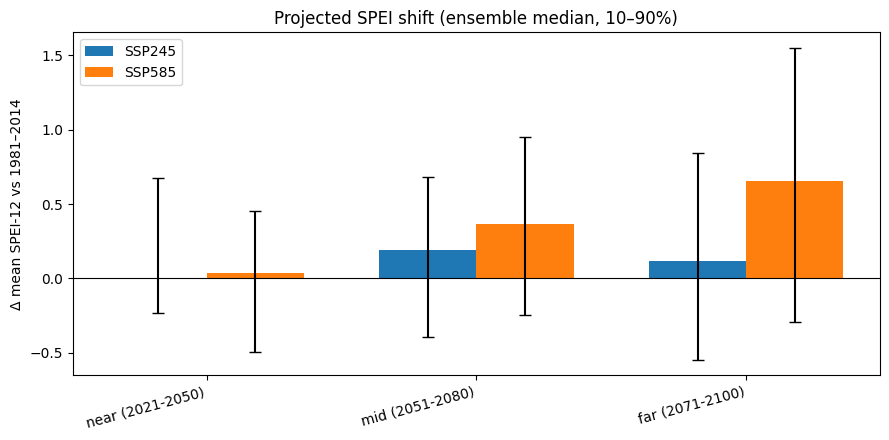

In [ ]:
def plot_shifts(ens, station=None):
    df = ens if station is None else ens[ens.station==station]
    wins = list(FUTURE_WINDOWS.keys())
    fig, ax = plt.subplots(figsize=(9,4.5))
    width = 0.36
    for i, scen in enumerate(SCENARIOS):
        sub = (df[df.scenario==scen].groupby("window")
               .agg(m=("spei_shift_median","mean"),
                    lo=("spei_shift_p10","mean"),
                    hi=("spei_shift_p90","mean"))
               .reindex(wins))
        x = np.arange(len(wins)) + (i-0.5)*width
        ax.bar(x, sub["m"], width,
               yerr=[sub["m"]-sub["lo"], sub["hi"]-sub["m"]],
               capsize=4, label=scen.upper())
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(np.arange(len(wins))); ax.set_xticklabels(wins, rotation=15, ha="right")
    ax.set_ylabel("\u0394 mean SPEI-12 vs 1981\u20132014")
    ax.set_title(f"Projected SPEI shift{'' if station is None else ' \u2014 '+station} (ensemble median, 10\u201390%)")
    ax.legend(); fig.tight_layout()
    return fig

fig = plot_shifts(ens)
fig.savefig(os.path.join(OUTPUT_DIR, "spei_shift_ensemble.png"), dpi=150)
plt.show()

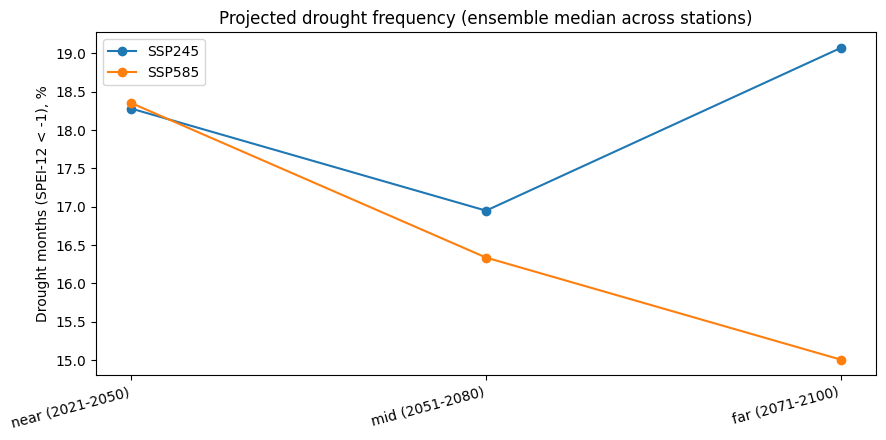

In [ ]:
def plot_drought_freq(ens):
    wins = list(FUTURE_WINDOWS.keys())
    fig, ax = plt.subplots(figsize=(9,4.5))
    for scen in SCENARIOS:
        sub = (ens[ens.scenario==scen].groupby("window")["drought_freq_median"]
               .mean().reindex(wins))
        ax.plot(wins, sub.values*100, marker="o", label=scen.upper())
    ax.set_ylabel("Drought months (SPEI-12 < -1), %")
    ax.set_title("Projected drought frequency (ensemble median across stations)")
    ax.set_xticklabels(wins, rotation=15, ha="right")
    ax.legend(); fig.tight_layout()
    return fig

fig2 = plot_drought_freq(ens)
fig2.savefig(os.path.join(OUTPUT_DIR, "drought_frequency.png"), dpi=150)
plt.show()

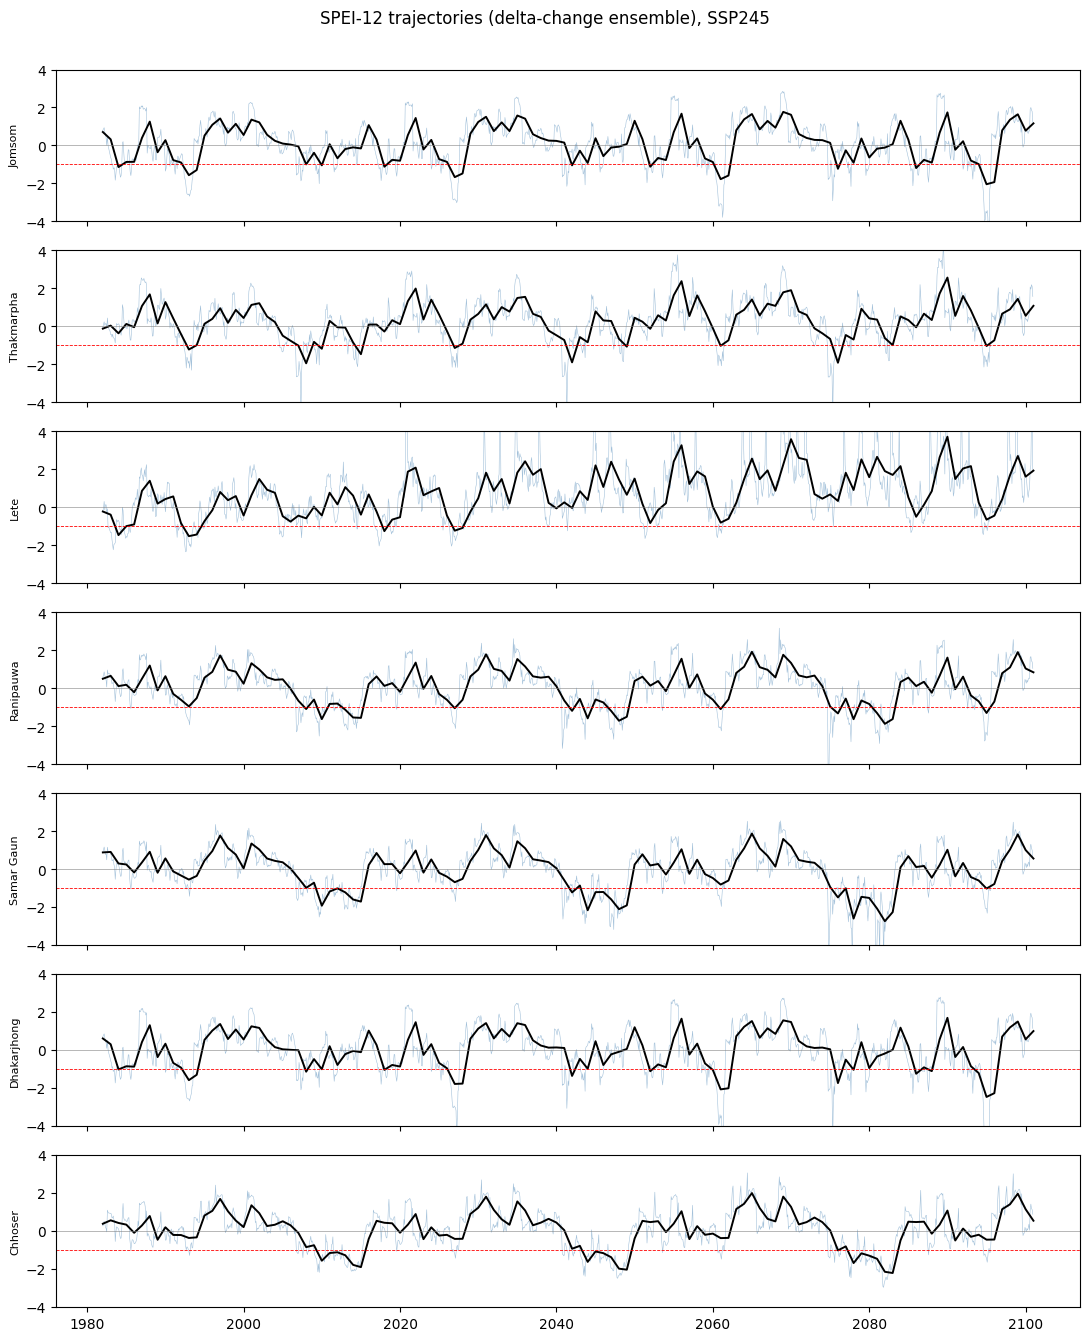

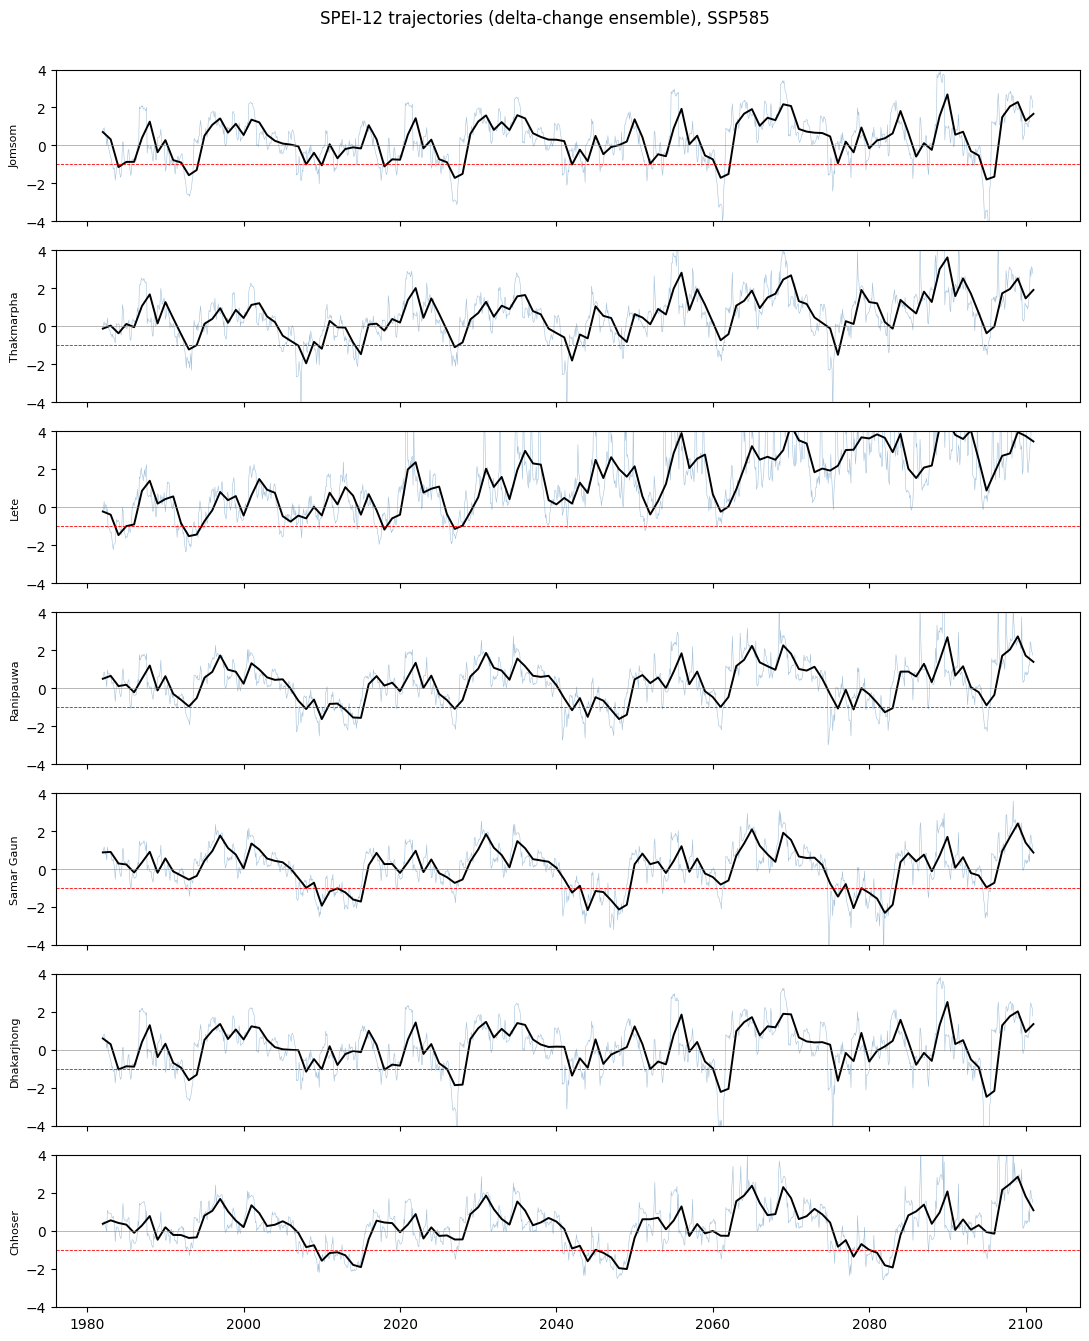

Point-data CSVs (monthly P/Tmax/Tmin/Tmean/PET/SPI12/SPEI12) saved in: C:\Users\Apechhya Aryal\Desktop\forpaper\outputs_cmip6\point_data
One file per station x scenario: 14 files


,station,scenario,spei_trend,spei_p,spei_slope,spei_changeyr,spei_cp_p,spi_trend,spi_p,spi_slope
0,Jomsom,ssp245,no trend,0.814,0.001,2028,0.413,increasing,0.000,0.010
1,Thakmarpha,ssp245,no trend,0.173,0.004,2052,0.075,no trend,NaN,0.011
2,Lete,ssp245,no trend,NaN,0.017,2030,0.000,increasing,0.000,0.016
3,Ranipauwa,ssp245,no trend,0.934,-0.000,2005,0.589,increasing,0.007,0.012
4,Samar Gaun,ssp245,no trend,0.340,-0.003,2005,0.134,increasing,0.011,0.012
5,Dhakarjhong,ssp245,no trend,0.924,-0.000,2028,0.851,increasing,0.000,0.009
6,Chhoser,ssp245,no trend,0.928,-0.000,2006,0.561,increasing,0.007,0.011
7,Jomsom,ssp585,no trend,0.099,0.006,2062,0.005,increasing,0.000,0.020
8,Thakmarpha,ssp585,increasing,0.001,0.013,2052,0.000,no trend,NaN,0.024
9,Lete,ssp585,increasing,0.000,0.035,2044,0.000,increasing,0.000,0.033


In [ ]:
# ===== Continuous 1981-2100 point-data + trajectories for ALL stations & scenarios =====
def _window_center(yr_range):
    return (yr_range[0] + yr_range[1]) / 2.0

def ensemble_window_deltas(station, scenario):
    """Ensemble-mean monthly deltas per future window, using the cached grid data (_PRELOAD)."""
    global _PRELOAD
    if _PRELOAD is None:
        scen_folders = [SCN_HIST] + [SCN_MAP[s] for s in SCENARIOS]
        print("Reading grid files once...")
        _PRELOAD = preload_station_data(STATIONS, GCMS, scen_folders)
    P = _PRELOAD; scf = SCN_MAP[scenario]
    out = {_window_center(BASELINE): {m: (0.0, 0.0, 1.0) for m in range(1, 13)}}
    for wlabel, (y0, y1) in FUTURE_WINDOWS.items():
        per_model = []
        for model in GCMS:
            dh = P.get((model, SCN_HIST), {}); df_ = P.get((model, scf), {})
            if not all(v in dh for v in ["P","Tmax","Tmin"]): continue
            if not all(v in df_ for v in ["P","Tmax","Tmin"]): continue
            if station not in dh["P"].columns or station not in df_["P"].columns: continue
            mh = slice_years(pd.concat({v: dh[v][station] for v in ["P","Tmax","Tmin"]}, axis=1), *BASELINE)
            mf = slice_years(pd.concat({v: df_[v][station] for v in ["P","Tmax","Tmin"]}, axis=1), y0, y1)
            if len(mf) == 0 or len(mh) == 0: continue
            per_model.append(monthly_deltas(mh, mf))
        if not per_model: continue
        out[_window_center((y0, y1))] = {
            m: (float(np.mean([d[m][0] for d in per_model])),
                float(np.mean([d[m][1] for d in per_model])),
                float(np.mean([d[m][2] for d in per_model]))) for m in range(1, 13)}
    return out

def interp_delta(win_deltas, year):
    centers = sorted(win_deltas)
    return {m: (float(np.interp(year, centers, [win_deltas[c][m][0] for c in centers])),
                float(np.interp(year, centers, [win_deltas[c][m][1] for c in centers])),
                float(np.interp(year, centers, [win_deltas[c][m][2] for c in centers])))
            for m in range(1, 13)}

def transient_frame(station, scenario, scale=12, future_end=2100):
    """Monthly 1981-future_end point data + indices for one station/scenario.
    Columns: P (mm), Tmax, Tmin, Tmean (degC), PET (mm), SPI12, SPEI12."""
    lat = STATIONS[station][0]
    obs = slice_years(load_observed_station(station), *BASELINE).copy()
    obs = obs[~((obs.index.month == 2) & (obs.index.day == 29))]
    win_deltas = ensemble_window_deltas(station, scenario)
    donor = list(range(BASELINE[0], BASELINE[1] + 1))
    frames = [obs[["P","Tmax","Tmin"]].copy()]
    for k, Y in enumerate(range(BASELINE[1] + 1, future_end + 1)):
        d = obs[obs.index.year == donor[k % len(donor)]][["P","Tmax","Tmin"]]
        pert = apply_deltas(d, interp_delta(win_deltas, Y))
        pert.index = pd.to_datetime(dict(year=Y, month=d.index.month, day=d.index.day))
        frames.append(pert)
    daily = pd.concat(frames).sort_index()
    daily["PET"] = hargreaves_pet_daily(daily["Tmax"], daily["Tmin"], lat, PET_SCALE)
    mon = daily.resample("MS").agg({"P":"sum","PET":"sum","Tmax":"mean","Tmin":"mean"})
    mon["Tmean"] = (mon["Tmax"] + mon["Tmin"]) / 2
    mon["SPI12"]  = standardize(mon["P"], scale, SPI_DIST, BASELINE)
    mon["SPEI12"] = standardize(mon["P"] - mon["PET"], scale, SPEI_DIST, BASELINE)
    mon.index.name = "date"
    return mon[["P","Tmax","Tmin","Tmean","PET","SPI12","SPEI12"]]

# ---- run for every station and scenario ----
PT_DIR = os.path.join(OUTPUT_DIR, "point_data"); os.makedirs(PT_DIR, exist_ok=True)
trend_rows = []
for scen in SCENARIOS:
    n = len(STATIONS)
    fig, axes = plt.subplots(n, 1, figsize=(11, 1.9*n), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, st in zip(axes, STATIONS):
        mon = transient_frame(st, scen)
        mon.to_csv(os.path.join(PT_DIR, f"point_{st.replace(' ','_')}_{scen}.csv"))
        ann_spei = mon["SPEI12"].resample("YE").mean()
        ann_spi  = mon["SPI12"].resample("YE").mean()
        ax.plot(mon.index, mon["SPEI12"], lw=0.4, alpha=0.5, color="steelblue")
        ax.plot(ann_spei.index, ann_spei.values, lw=1.4, color="k")
        ax.axhline(-1, color="r", ls="--", lw=0.6); ax.axhline(0, color="grey", lw=0.4)
        ax.set_ylabel(st, fontsize=8); ax.set_ylim(-4, 4)
        eMK, eCP = mk_trend(ann_spei.dropna().values), pettitt_change(ann_spei.dropna())
        iMK = mk_trend(ann_spi.dropna().values)
        trend_rows.append(dict(
            station=st, scenario=scen,
            spei_trend=eMK["trend"], spei_p=round(eMK["p"],4), spei_slope=round(eMK["slope"],4),
            spei_changeyr=getattr(eCP.get("cp_date", None), "year", None), spei_cp_p=round(eCP["p"],4),
            spi_trend=iMK["trend"], spi_p=round(iMK["p"],4), spi_slope=round(iMK["slope"],4)))
    fig.suptitle(f"SPEI-12 trajectories (delta-change ensemble), {scen.upper()}", y=1.005)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, f"spei_trajectories_all_{scen}.png"), dpi=150, bbox_inches="tight")
    plt.show()

trend_summary = pd.DataFrame(trend_rows)
trend_summary.to_csv(os.path.join(OUTPUT_DIR, "trend_changepoint_summary.csv"), index=False)
print("Point-data CSVs (monthly P/Tmax/Tmin/Tmean/PET/SPI12/SPEI12) saved in:", PT_DIR)
print("One file per station x scenario:", len(STATIONS)*len(SCENARIOS), "files")
trend_summary

## Observed + projected precipitation & temperature (ensemble, all stations)

For each station: observed annual precipitation and mean temperature (1981-2014) joined to the
**projected** future (2015-2100) under SSP2-4.5 and SSP5-8.5, with the **ensemble median and
10-90% spread across the 13 GCMs**. Saves a figure and a CSV per station.

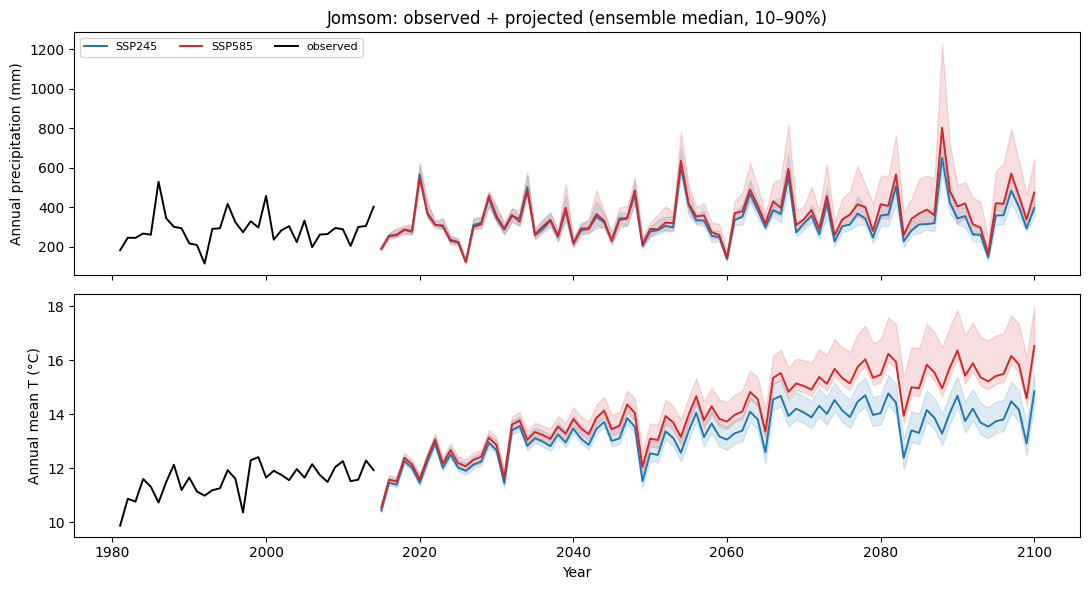

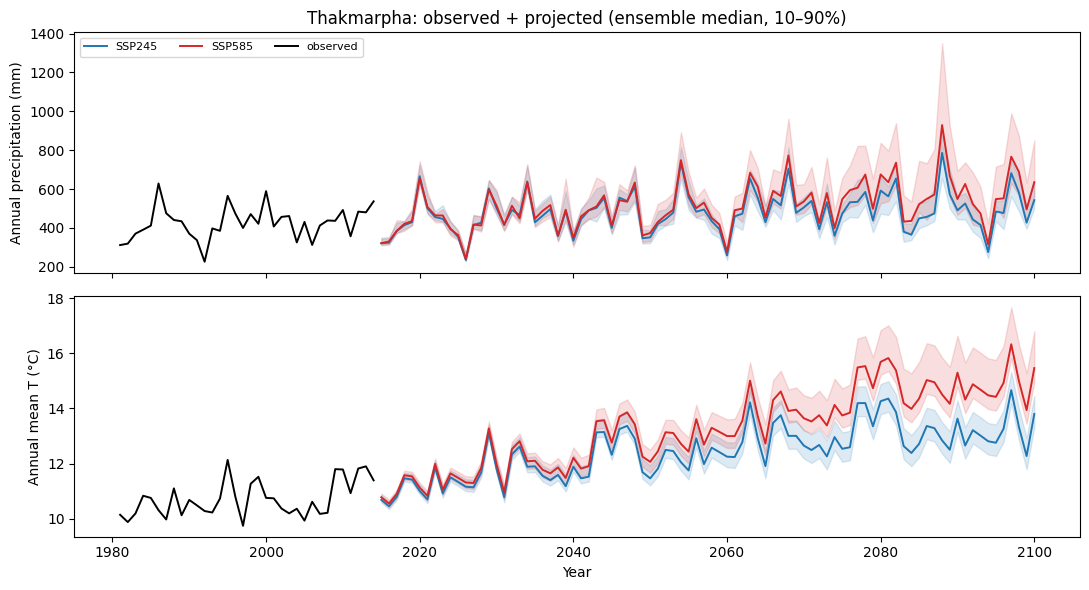

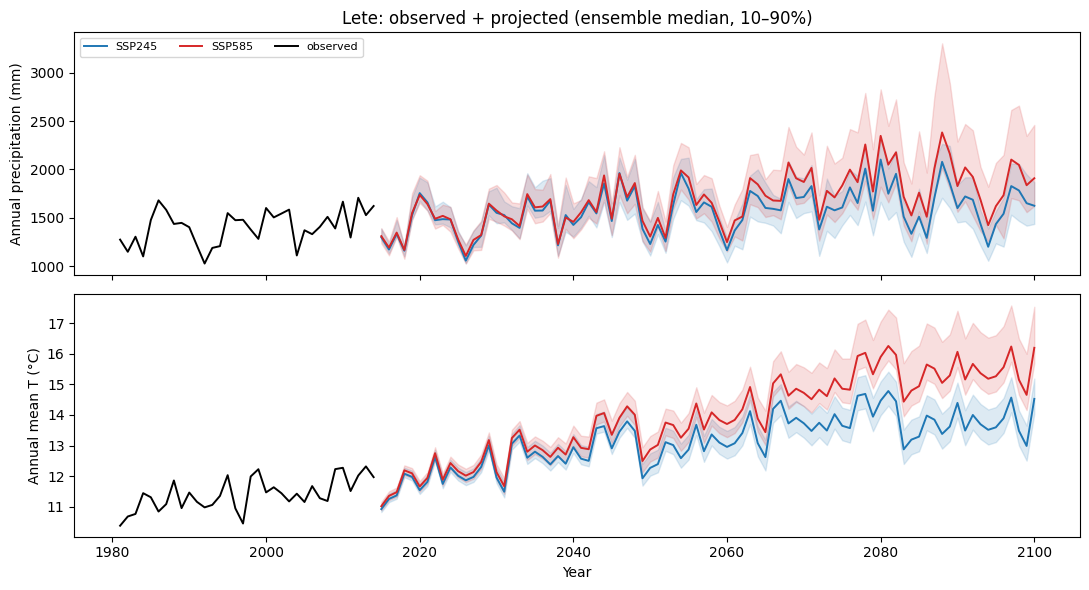

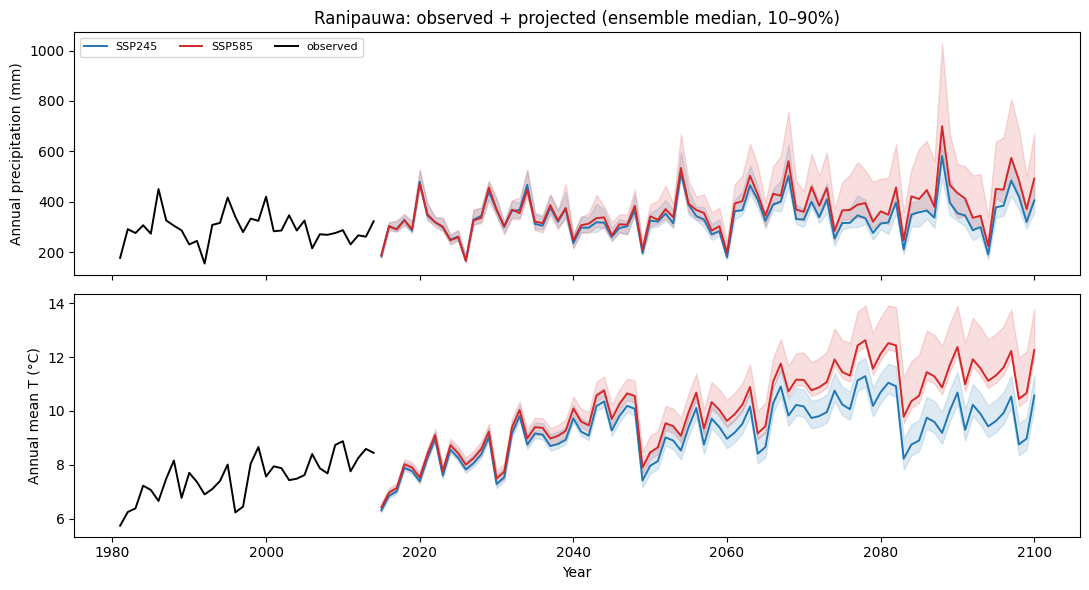

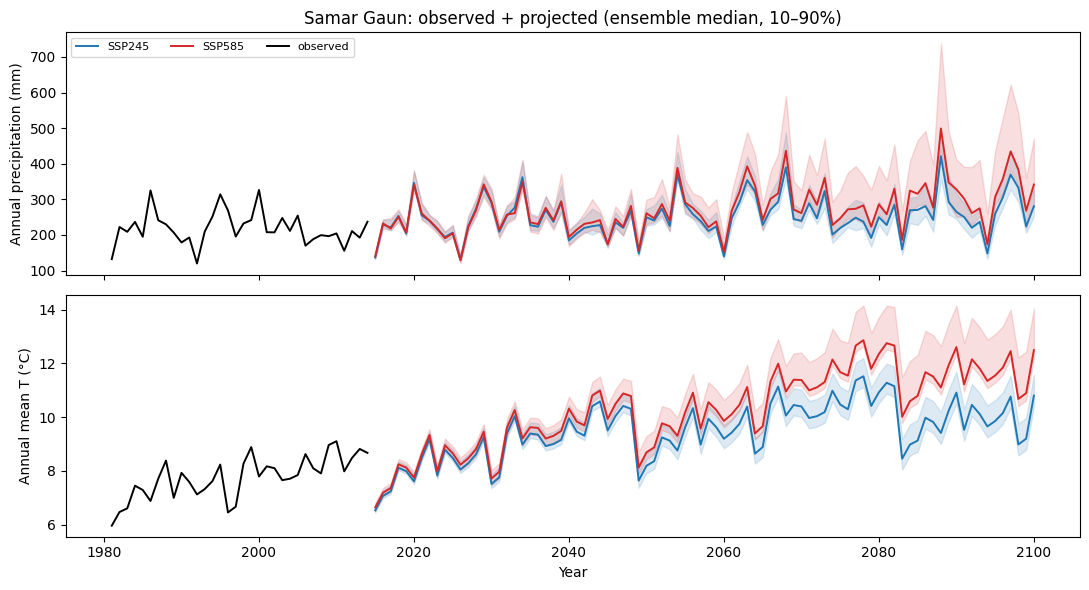

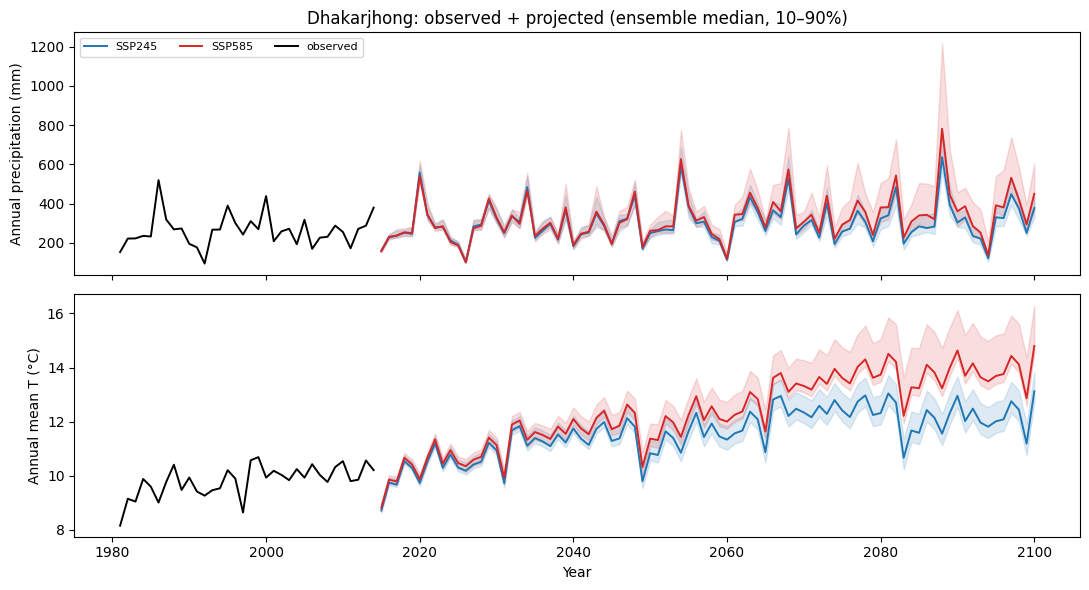

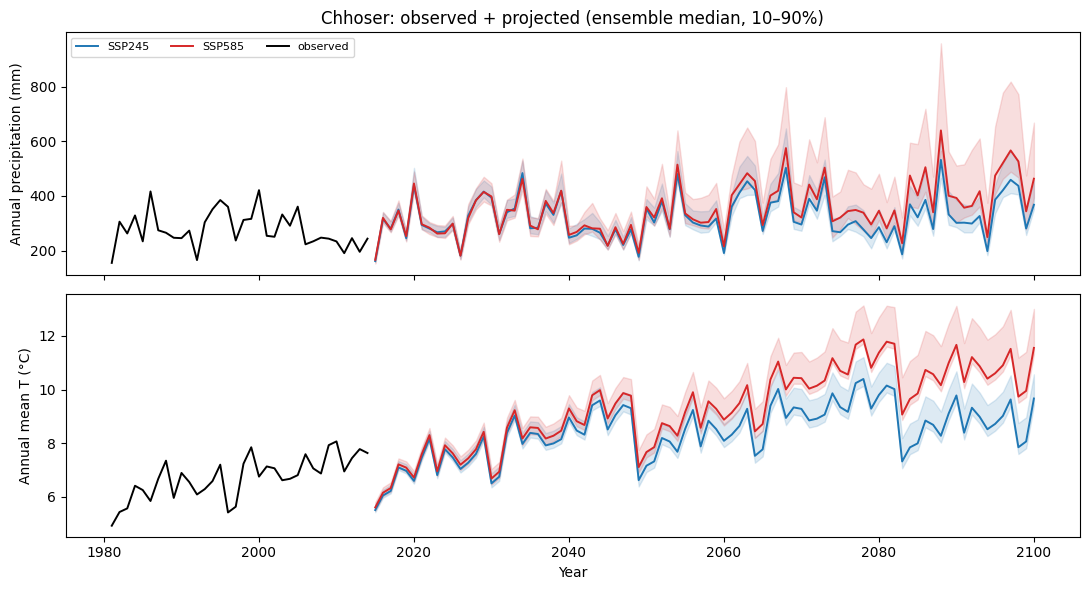

Saved observed+projected P/T per station to: C:\Users\Apechhya Aryal\Desktop\forpaper\outputs_cmip6\climate_point_data
Files: 7 CSVs + 7 figures


In [ ]:
def per_gcm_window_deltas(station, scenario):
    """Per-GCM monthly deltas by window center year, from the cached grid data."""
    global _PRELOAD
    if _PRELOAD is None:
        scen_folders=[SCN_HIST]+[SCN_MAP[s] for s in SCENARIOS]
        print("Reading grid files once...")
        _PRELOAD=preload_station_data(STATIONS, GCMS, scen_folders)
    P=_PRELOAD; scf=SCN_MAP[scenario]; res={}
    for model in GCMS:
        dh=P.get((model,SCN_HIST),{}); df_=P.get((model,scf),{})
        if not all(v in dh for v in ["P","Tmax","Tmin"]): continue
        if not all(v in df_ for v in ["P","Tmax","Tmin"]): continue
        if station not in dh["P"].columns or station not in df_["P"].columns: continue
        mh=slice_years(pd.concat({v:dh[v][station] for v in ["P","Tmax","Tmin"]},axis=1),*BASELINE)
        wd={_window_center(BASELINE):{m:(0.,0.,1.) for m in range(1,13)}}
        for wlabel,(y0,y1) in FUTURE_WINDOWS.items():
            mf=slice_years(pd.concat({v:df_[v][station] for v in ["P","Tmax","Tmin"]},axis=1),y0,y1)
            if len(mf)>0 and len(mh)>0:
                wd[_window_center((y0,y1))]=monthly_deltas(mh,mf)
        res[model]=wd
    return res

def climate_trajectories(station, scenario, future_end=2100):
    """Return (observed_annual_df, future_ensemble_df) of annual P and Tmean."""
    obs=slice_years(load_observed_station(station),*BASELINE).copy()
    obs=obs[~((obs.index.month==2)&(obs.index.day==29))]
    obs_ann=pd.DataFrame({"P":obs["P"].resample("YE").sum(),
                          "Tmean":((obs["Tmax"]+obs["Tmin"])/2).resample("YE").mean()})
    obs_ann.index=obs_ann.index.year
    donor=list(range(BASELINE[0],BASELINE[1]+1))
    Pby={}; Tby={}
    for model,wd in per_gcm_window_deltas(station,scenario).items():
        frames=[]
        for k,Y in enumerate(range(BASELINE[1]+1,future_end+1)):
            d=obs[obs.index.year==donor[k%len(donor)]][["P","Tmax","Tmin"]]
            pert=apply_deltas(d, interp_delta(wd,Y))
            pert.index=pd.to_datetime(dict(year=Y,month=d.index.month,day=d.index.day))
            frames.append(pert)
        fut=pd.concat(frames).sort_index()
        Pa=fut["P"].resample("YE").sum(); Pa.index=Pa.index.year
        Ta=((fut["Tmax"]+fut["Tmin"])/2).resample("YE").mean(); Ta.index=Ta.index.year
        for y in Pa.index:
            Pby.setdefault(y,[]).append(Pa[y]); Tby.setdefault(y,[]).append(Ta[y])
    yrs=sorted(Pby)
    fut_ens=pd.DataFrame({"year":yrs,
        "P_median":[np.median(Pby[y]) for y in yrs],
        "P_p10":[np.percentile(Pby[y],10) for y in yrs],
        "P_p90":[np.percentile(Pby[y],90) for y in yrs],
        "Tmean_median":[np.median(Tby[y]) for y in yrs],
        "Tmean_p10":[np.percentile(Tby[y],10) for y in yrs],
        "Tmean_p90":[np.percentile(Tby[y],90) for y in yrs]}).set_index("year")
    return obs_ann, fut_ens

CLIM_DIR=os.path.join(OUTPUT_DIR,"climate_point_data"); os.makedirs(CLIM_DIR,exist_ok=True)
scen_colors=dict(zip(SCENARIOS, ["tab:blue","tab:red","tab:green","tab:orange"]))
for st in STATIONS:
    fig,(axP,axT)=plt.subplots(2,1,figsize=(11,6),sharex=True)
    rows=[]; obs_ann=None
    for scen in SCENARIOS:
        col=scen_colors[scen]
        obs_ann, fut=climate_trajectories(st, scen)
        axP.plot(fut.index, fut["P_median"], color=col, lw=1.4, label=scen.upper())
        axP.fill_between(fut.index, fut["P_p10"], fut["P_p90"], color=col, alpha=0.15)
        axT.plot(fut.index, fut["Tmean_median"], color=col, lw=1.4, label=scen.upper())
        axT.fill_between(fut.index, fut["Tmean_p10"], fut["Tmean_p90"], color=col, alpha=0.15)
        for y in fut.index:
            rows.append(dict(station=st, period=scen, year=int(y),
                P=round(fut.loc[y,"P_median"],1), P_p10=round(fut.loc[y,"P_p10"],1), P_p90=round(fut.loc[y,"P_p90"],1),
                Tmean=round(fut.loc[y,"Tmean_median"],2), Tmean_p10=round(fut.loc[y,"Tmean_p10"],2), Tmean_p90=round(fut.loc[y,"Tmean_p90"],2)))
    axP.plot(obs_ann.index, obs_ann["P"], color="k", lw=1.4, label="observed")
    axT.plot(obs_ann.index, obs_ann["Tmean"], color="k", lw=1.4, label="observed")
    for y in obs_ann.index:
        rows.append(dict(station=st, period="observed", year=int(y),
            P=round(obs_ann.loc[y,"P"],1), P_p10=np.nan, P_p90=np.nan,
            Tmean=round(obs_ann.loc[y,"Tmean"],2), Tmean_p10=np.nan, Tmean_p90=np.nan))
    axP.set_ylabel("Annual precipitation (mm)"); axT.set_ylabel("Annual mean T (\u00b0C)")
    axT.set_xlabel("Year"); axP.set_title(f"{st}: observed + projected (ensemble median, 10\u201390%)")
    axP.legend(fontsize=8, ncol=3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, f"climate_{st.replace(' ','_')}.png"), dpi=150)
    plt.show()
    pd.DataFrame(rows).sort_values(["period","year"]).to_csv(
        os.path.join(CLIM_DIR, f"climate_{st.replace(' ','_')}.csv"), index=False)

print("Saved observed+projected P/T per station to:", CLIM_DIR)
print("Files:", len(STATIONS), "CSVs +", len(STATIONS), "figures")

## Robustness: model agreement + temperature-amplification gap

How many of the 13 models actually agree on the direction of change, and how much of the
precipitation gain is offset by rising PET. `temp_amplification` = SPI shift - SPEI shift:
the larger it is, the more warming-driven PET is eating into the rainfall gains.

In [ ]:
def agreement(results):
    rows=[]
    for (scen,win),g in results.groupby(["scenario","window"]):
        gt=g.dropna(subset=["spei_shift"])
        n=len(gt)
        dry=int((gt["spei_shift"]<0).sum())
        rows.append(dict(scenario=scen, window=win, n_cases=n,
            cases_drying=dry, cases_wetting=n-dry,
            pct_drying=round(100*dry/n,0) if n else np.nan,
            spi_shift_median=round(g["spi_mean"].median(),3),
            spei_shift_median=round(gt["spei_shift"].median(),3),
            temp_amplification=round(g["spi_mean"].median()-gt["spei_shift"].median(),3)))
    return pd.DataFrame(rows)

agree = agreement(results)
agree.to_csv(os.path.join(OUTPUT_DIR,"model_agreement.csv"), index=False)
print("Model agreement (across all station x model cases):")
print(agree.to_string(index=False))

# per-station direction count (which stations dry vs wet)
print("\nPer-station median SPEI shift (SSP585, far future):")
sub=results[(results.scenario=="ssp585") & (results.window.str.startswith("far"))]
print(sub.groupby("station")["spei_shift"].median().round(3).sort_values().to_string())

Model agreement (across all station x model cases):
scenario           window  n_cases  cases_drying  cases_wetting  pct_drying  spi_shift_median  spei_shift_median  temp_amplification
  ssp245  far (2071-2100)       91            47             44      52.000             0.815             -0.012               0.827
  ssp245  mid (2051-2080)       91            43             48      47.000             0.710              0.033               0.677
  ssp245 near (2021-2050)       91            45             46      49.000             0.352              0.001               0.352
  ssp585  far (2071-2100)       91            26             65      29.000             1.653              0.419               1.234
  ssp585  mid (2051-2080)       91            36             55      40.000             1.057              0.146               0.911
  ssp585 near (2021-2050)       91            43             48      47.000             0.412              0.007               0.405

Per-station medi

## PET sensitivity (Hargreaves coefficient sweep)

Because the wet/dry sign depends on how much PET is allowed to rise, re-run the SPEI shift at
PET_SCALE = 0.33, 0.66, 1.0. If the sign holds across all three, the conclusion is robust;
if it flips, report the range. Reuses the cached grid data, so this is fast.

In [ ]:
_orig_scale = PET_SCALE
sens=[]
for ps in [0.33, 0.5, 1.0]:
    PET_SCALE = ps
    r = run_pipeline(scale=12, reuse=True)      # grid cache reused
    s = r.groupby(["scenario","window"])["spei_shift"].median().reset_index()
    s["PET_SCALE"] = ps
    sens.append(s)
PET_SCALE = _orig_scale                          # restore
sens = pd.concat(sens, ignore_index=True)
pivot = sens.pivot_table(index=["scenario","window"], columns="PET_SCALE",
                         values="spei_shift").round(3)
pivot.to_csv(os.path.join(OUTPUT_DIR,"pet_sensitivity.csv"))
print("Median SPEI shift vs PET_SCALE (sign should be checked for robustness):")
print(pivot.to_string())

Median SPEI shift vs PET_SCALE (sign should be checked for robustness):
PET_SCALE                  0.330  0.500  1.000
scenario window                               
ssp245   far (2071-2100)   0.649  0.470 -0.012
         mid (2051-2080)   0.520  0.385  0.033
         near (2021-2050)  0.239  0.145  0.001
ssp585   far (2071-2100)   1.169  1.041  0.419
         mid (2051-2080)   0.750  0.602  0.146
         near (2021-2050)  0.291  0.208  0.007


In [ ]:
results.to_csv(os.path.join(OUTPUT_DIR, "per_model_results.csv"), index=False)
ens.to_csv(os.path.join(OUTPUT_DIR, "ensemble_results.csv"), index=False)
print("Saved to", OUTPUT_DIR)
ens

Saved to C:\Users\Apechhya Aryal\Desktop\forpaper\outputs_cmip6


,station,scenario,window,has_temp,spi_mean_median,spi_drought_median,spei_shift_median,spei_shift_p10,spei_shift_p90,drought_freq_median,dTmax_median,Pfactor_median,n_models
0,Chhoser,ssp245,far (2071-2100),True,0.815,0.060,0.058,-0.508,0.371,0.237,2.023,1.107,13
1,Chhoser,ssp245,mid (2051-2080),True,0.713,0.073,-0.008,-0.341,0.293,0.219,1.761,1.097,13
2,Chhoser,ssp245,near (2021-2050),True,0.434,0.091,-0.005,-0.236,0.443,0.207,1.027,1.032,13
3,Chhoser,ssp585,far (2071-2100),True,1.653,0.003,0.193,-0.497,1.296,0.217,4.070,1.256,13
4,Chhoser,ssp585,mid (2051-2080),True,1.057,0.025,-0.066,-0.450,0.666,0.239,2.928,1.137,13
5,Chhoser,ssp585,near (2021-2050),True,0.560,0.081,-0.069,-0.600,0.210,0.222,1.298,1.051,13
6,Dhakarjhong,ssp245,far (2071-2100),True,0.713,0.060,-0.204,-0.690,0.480,0.229,2.082,1.100,13
7,Dhakarjhong,ssp245,mid (2051-2080),True,0.562,0.050,-0.029,-0.507,0.376,0.196,1.730,1.061,13
8,Dhakarjhong,ssp245,near (2021-2050),True,0.257,0.078,-0.111,-0.220,0.391,0.191,0.988,1.025,13
9,Dhakarjhong,ssp585,far (2071-2100),True,1.128,0.033,0.117,-0.722,0.846,0.161,3.870,1.253,13


## Enhancement 1 — Multi-timescale drought (SPI/SPEI 3, 6, 12)
SPEI-3 ~ agricultural/seasonal drought, SPEI-12 ~ hydrological. Reusing the cached grid.

In [ ]:
def run_multiscale(scales=None):
    out=[]
    for ts in (scales or TIMESCALES):
        r=run_pipeline(scale=ts, reuse=True); r["timescale"]=ts; out.append(r)
    return pd.concat(out, ignore_index=True)

multiscale=run_multiscale()
ms_sum=(multiscale.groupby(["timescale","scenario","window"])
        .agg(spi_shift=("spi_mean","median"),
             spei_shift=("spei_shift","median"),
             drought_freq=("drought_freq","median"),
             pct_drying=("spei_shift", lambda x: round(100*(x.dropna()<0).mean()) if x.notna().any() else np.nan))
        .reset_index())
ms_sum["robust_signal"]=np.where((ms_sum.pct_drying>=70)|(ms_sum.pct_drying<=30),"yes","no (models split)")
ms_sum.to_csv(os.path.join(OUTPUT_DIR,"multitimescale_summary.csv"), index=False)
print("Multi-timescale SPEI/SPI shift (median across stations & models):")
print(ms_sum.to_string(index=False))

Multi-timescale SPEI/SPI shift (median across stations & models):
 timescale scenario           window  spi_shift  spei_shift  drought_freq  pct_drying     robust_signal
         3   ssp245  far (2071-2100)      0.336      -0.373         0.313          79               yes
         3   ssp245  mid (2051-2080)      0.316      -0.284         0.291          75               yes
         3   ssp245 near (2021-2050)      0.180      -0.188         0.219          75               yes
         3   ssp585  far (2071-2100)      0.654      -0.542         0.401          74               yes
         3   ssp585  mid (2051-2080)      0.448      -0.386         0.333          75               yes
         3   ssp585 near (2021-2050)      0.206      -0.203         0.239          78               yes
         6   ssp245  far (2071-2100)      0.519      -0.234         0.270          66 no (models split)
         6   ssp245  mid (2051-2080)      0.456      -0.157         0.251          71               ye

## Enhancement 2 — Seasonal change (winter / pre-monsoon / monsoon / post-monsoon)


Far-future seasonal change (median across stations & models):
scenario            season  P_change_pct    dT
  ssp245      DJF (winter)       -14.500 3.110
  ssp245    JJAS (monsoon)        26.900 2.710
  ssp245 MAM (pre-monsoon)        13.300 2.380
  ssp245 ON (post-monsoon)         6.600 2.270
  ssp585      DJF (winter)       -19.500 5.290
  ssp585    JJAS (monsoon)        70.200 4.790
  ssp585 MAM (pre-monsoon)        22.700 4.420
  ssp585 ON (post-monsoon)        42.600 4.240


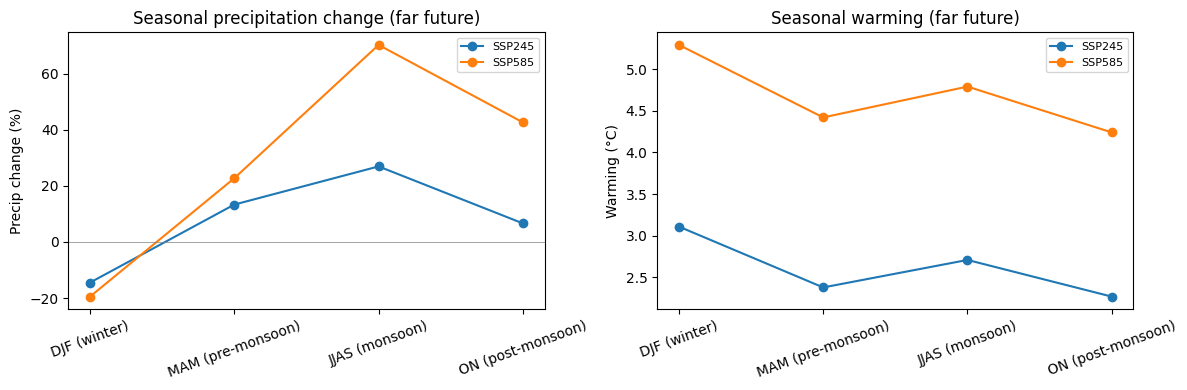

In [ ]:
SEASONS={"DJF (winter)":[12,1,2],"MAM (pre-monsoon)":[3,4,5],
         "JJAS (monsoon)":[6,7,8,9],"ON (post-monsoon)":[10,11]}
rows=[]; base_c=_window_center(BASELINE)
for st in STATIONS:
    for scen in SCENARIOS:
        wd=ensemble_window_deltas(st,scen)
        for center,mdv in wd.items():
            if center==base_c: continue
            for season,mns in SEASONS.items():
                dT=float(np.mean([(mdv[m][0]+mdv[m][1])/2 for m in mns]))
                fP=float(np.mean([mdv[m][2] for m in mns]))
                rows.append(dict(station=st,scenario=scen,window_center=center,
                                 season=season,dT=round(dT,2),P_change_pct=round(100*(fP-1),1)))
seasonal=pd.DataFrame(rows)
seasonal.to_csv(os.path.join(OUTPUT_DIR,"seasonal_change.csv"),index=False)
far_c=seasonal.window_center.max()
ss=(seasonal[seasonal.window_center==far_c].groupby(["scenario","season"])
    .agg(P_change_pct=("P_change_pct","median"),dT=("dT","median")).reset_index())
print("Far-future seasonal change (median across stations & models):")
print(ss.to_string(index=False))
seasons=list(SEASONS)
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
for scen in SCENARIOS:
    d=ss[ss.scenario==scen].set_index("season").reindex(seasons)
    a1.plot(seasons,d["P_change_pct"],marker="o",label=scen.upper())
    a2.plot(seasons,d["dT"],marker="o",label=scen.upper())
a1.axhline(0,color="grey",lw=0.5); a1.set_ylabel("Precip change (%)")
a1.set_title("Seasonal precipitation change (far future)")
a2.set_ylabel("Warming (\u00b0C)"); a2.set_title("Seasonal warming (far future)")
for a in (a1,a2): a.legend(fontsize=8); a.tick_params(axis="x",rotation=20)
fig.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"seasonal_change.png"),dpi=150); plt.show()

## Enhancement 3 — Drought characteristics (run theory)
A drought event = consecutive months with SPEI-12 < threshold. Reports frequency, mean
duration, severity and the worst event, per period — far richer than '% drought months'.

In [ ]:
def drought_events(spei, threshold=DROUGHT_THRESHOLD):
    spei=pd.Series(spei).dropna().values
    ev=[]; dur=0; sev=0.0
    for s in spei:
        if s<threshold: dur+=1; sev+=abs(s)
        elif dur>0: ev.append((dur,sev)); dur=0; sev=0.0
    if dur>0: ev.append((dur,sev))
    if not ev: return (0,0.0,0.0,0)
    return (len(ev), float(np.mean([e[0] for e in ev])),
            float(np.mean([e[1] for e in ev])), int(max(e[0] for e in ev)))

PERIODS={"baseline (1981-2014)":BASELINE}; PERIODS.update(FUTURE_WINDOWS)
rows=[]
for st in STATIONS:
    for scen in SCENARIOS:
        tf=transient_frame(st,scen)["SPEI12"]
        for pname,(y0,y1) in PERIODS.items():
            sl=tf[(tf.index.year>=y0)&(tf.index.year<=y1)]
            n,mdur,msev,mx=drought_events(sl)
            rows.append(dict(station=st,scenario=scen,period=pname,
                events_per_decade=round(10*n/(y1-y0+1),2),
                mean_duration_months=round(mdur,1),
                mean_severity=round(msev,2), worst_duration_months=mx))
drchar=pd.DataFrame(rows)
drchar.to_csv(os.path.join(OUTPUT_DIR,"drought_characteristics.csv"),index=False)
print("Drought characteristics (run theory on SPEI-12, median across stations):")
print(drchar.groupby(["scenario","period"]).agg(
    events_per_decade=("events_per_decade","median"),
    mean_duration=("mean_duration_months","median"),
    mean_severity=("mean_severity","median"),
    worst_duration=("worst_duration_months","max")).round(2).to_string())

Drought characteristics (run theory on SPEI-12, median across stations):
                               events_per_decade  mean_duration  mean_severity  worst_duration
scenario period                                                                               
ssp245   baseline (1981-2014)              3.530          5.200          8.060              28
         far (2071-2100)                   4.000          4.600          8.630              31
         mid (2051-2080)                   3.330          5.500          8.930              19
         near (2021-2050)                  3.000          4.700          8.800              31
ssp585   baseline (1981-2014)              3.530          5.200          8.060              28
         far (2071-2100)                   3.670          4.300          9.290              29
         mid (2051-2080)                   3.000          3.800          6.370              18
         near (2021-2050)                  3.000          5.100         

## Enhancement 4 — CMIP6 historical validation at the stations
The Mishra dataset is already bias-corrected, so model-historical climatology (1981-2014) should
closely match your observations. Small biases here justify the delta-change approach.

In [ ]:
rows=[]; P=_PRELOAD
for st in STATIONS:
    obs=slice_years(load_observed_station(st),*BASELINE)
    oP=obs["P"].groupby(obs.index.month).mean()
    oT=((obs["Tmax"]+obs["Tmin"])/2).groupby(obs.index.month).mean()
    mp=[]; mt=[]
    for model in GCMS:
        dh=P.get((model,SCN_HIST),{})
        if not all(v in dh for v in ["P","Tmax","Tmin"]) or st not in dh["P"].columns: continue
        mh=slice_years(pd.concat({v:dh[v][st] for v in ["P","Tmax","Tmin"]},axis=1),*BASELINE)
        mp.append(mh["P"].groupby(mh.index.month).mean())
        mt.append(((mh["Tmax"]+mh["Tmin"])/2).groupby(mh.index.month).mean())
    if not mp: continue
    mP=pd.concat(mp,axis=1).mean(axis=1); mT=pd.concat(mt,axis=1).mean(axis=1)
    rows.append(dict(station=st,
        obs_annual_P=round(oP.sum()), mod_annual_P=round(mP.sum()),
        P_bias_pct=round(100*(mP.sum()-oP.sum())/oP.sum(),1),
        obs_Tmean=round(oT.mean(),2), mod_Tmean=round(mT.mean(),2),
        T_bias_degC=round(mT.mean()-oT.mean(),2)))
valid=pd.DataFrame(rows)
valid.to_csv(os.path.join(OUTPUT_DIR,"cmip6_historical_validation.csv"),index=False)
print("CMIP6 (bias-corrected) historical vs observed climatology, 1981-2014:")
print(valid.to_string(index=False))

CMIP6 (bias-corrected) historical vs observed climatology, 1981-2014:
    station  obs_annual_P  mod_annual_P  P_bias_pct  obs_Tmean  mod_Tmean  T_bias_degC
     Jomsom             9            28     201.500     11.500     -3.660      -15.160
 Thakmarpha            14            35     150.200     10.680      4.310       -6.370
       Lete            46            35     -24.500     11.380      4.310       -7.070
  Ranipauwa            10            28     192.600      7.500      2.440       -5.060
 Samar Gaun             7            28     295.100      7.720      2.440       -5.290
Dhakarjhong             9            28     230.400      9.770     -3.660      -13.430
    Chhoser             9            27     194.700      6.690     -0.030       -6.720


## Enhancement 5 — Monthly change heatmap (SSP585, far future)
Which months drive the change: precipitation change (%) and warming (degC) by station and month.

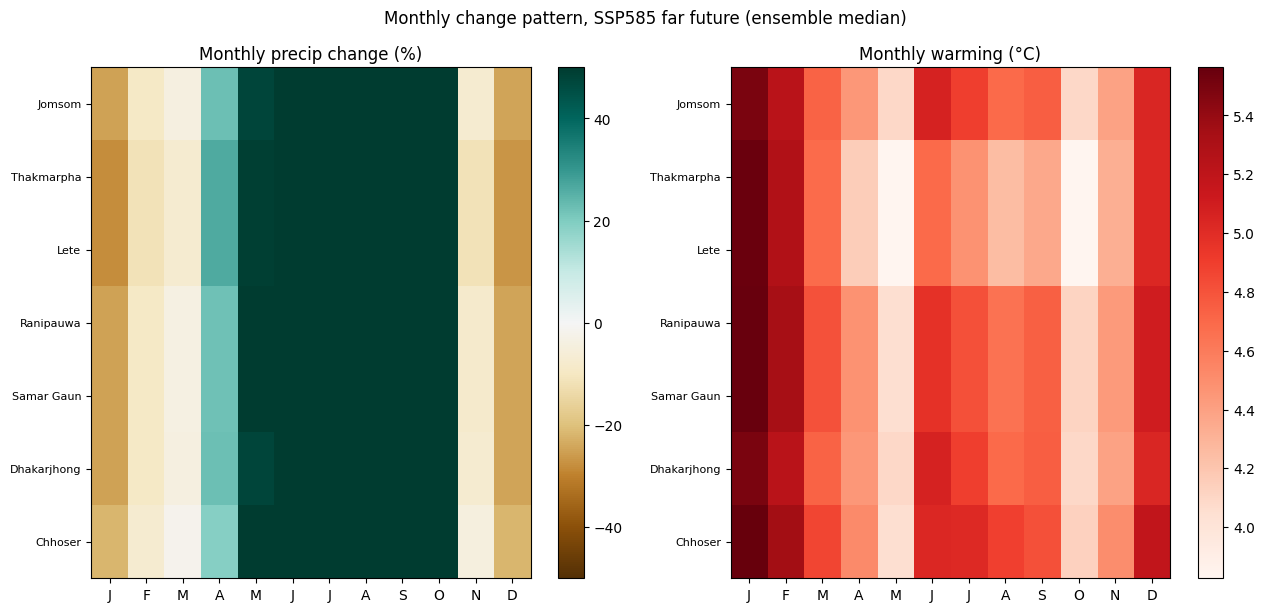

In [ ]:
far_label=list(FUTURE_WINDOWS)[-1]; fc=_window_center(FUTURE_WINDOWS[far_label])
sts=list(STATIONS); mns=list(range(1,13)); matP=[]; matT=[]
for st in sts:
    wd=ensemble_window_deltas(st,"ssp585"); mdv=wd.get(fc, wd[max(wd)])
    matP.append([100*(mdv[m][2]-1) for m in mns])
    matT.append([(mdv[m][0]+mdv[m][1])/2 for m in mns])
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,0.6*len(sts)+2))
im1=a1.imshow(matP,aspect="auto",cmap="BrBG",vmin=-50,vmax=50)
im2=a2.imshow(matT,aspect="auto",cmap="Reds")
a1.set_title("Monthly precip change (%)"); a2.set_title("Monthly warming (\u00b0C)")
for a in (a1,a2):
    a.set_xticks(range(12)); a.set_xticklabels(list("JFMAMJJASOND"))
    a.set_yticks(range(len(sts))); a.set_yticklabels(sts,fontsize=8)
fig.colorbar(im1,ax=a1); fig.colorbar(im2,ax=a2)
fig.suptitle("Monthly change pattern, SSP585 far future (ensemble median)")
fig.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"monthly_change_heatmap.png"),dpi=150); plt.show()

In [1]:
import gzip, shutil, os, glob

folder = r"C:\Users\Apechhya Aryal\Desktop\forpaper\code\aphrodite_tave"
for gz in glob.glob(os.path.join(folder, "*.gz")):
    out = gz[:-3]
    if not os.path.exists(out):
        with gzip.open(gz, "rb") as fin, open(out, "wb") as fout:
            shutil.copyfileobj(fin, fout)
    os.remove(gz)
print("nc files:", len(glob.glob(os.path.join(folder, "*.nc"))))

nc files: 35
